In [1]:
import onep
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy
from scipy import stats
import numpy as np
import scipy.stats
%matplotlib inline

In [ ]:
astro_3R = onep.InscopixProcessing(session='recall', animal='astro3', data_directory='/Users/suthardr/Desktop/')
astro_3R.read_inscopix()

astro_4R = onep.InscopixProcessing(session='recall', animal='astro4', data_directory='/Users/suthardr/Desktop/')
astro_4R.read_inscopix()

astro_5R = onep.InscopixProcessing(session='recall', animal='astro5', data_directory='/Users/suthardr/Desktop/')
astro_5R.read_inscopix()

astro_6R = onep.InscopixProcessing(session='recall', animal='astro6', data_directory='/Users/suthardr/Desktop/')
astro_6R.read_inscopix()

astro_7R = onep.InscopixProcessing(session='gen1', animal='astro7', data_directory='/Users/suthardr/Desktop/')
astro_7R.read_inscopix()

astro_8R = onep.InscopixProcessing(session='gen1', animal='astro8', data_directory='/Users/suthardr/Desktop/')
astro_8R.read_inscopix()

astro_9R = onep.InscopixProcessing(session='gen1', animal='astro9', data_directory='/Users/suthardr/Desktop/')
astro_9R.read_inscopix()

collection_cxta = onep.dCA1Group(astro_3R, astro_4R, astro_5R, astro_6R)
collection_cxtb = onep.dCA1Group(astro_7R, astro_8R, astro_9R)
collection_cxta.preprocess()
collection_cxtb.preprocess()

In [5]:
def sequence_heat_plot(unsorted_array, time, ax=None):
    """
    arr: N x T array of cell activity
    time: T array of time
    returns: ax
    """
    # z-score array
    arr = stats.zscore(unsorted_array, axis=1)
    # sort array based on argmax of each row
    arr, _ = onep.maxsort(arr)
    # make a figure
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    # plot the heatmap
    sns.heatmap(arr, cmap='mako',cbar=True, cbar_kws={"label": r"z-scored $\frac{dF}{F}$"})
    # set x-ticks
    ax.set_xticks(np.linspace(0, arr.shape[1], 5), np.linspace(np.min(time), np.max(time), 5))
    # ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.axvline((time.shape[0]/3), linestyle='--', color='white')
    # set labels
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Cells')
    plt.tight_layout()
    return ax, fig

In [3]:
#Save all Recall objects as pickle
import pickle
# List of objects to save
astros = [astro_3R, astro_4R, astro_5R, astro_6R, astro_7R, astro_8R, astro_9R]  # Add all the astros you want to save to this list

# Loop through each astro and save it
for i, astro in enumerate(astros, start=1):
    filename = f'/Users/suthardr/Desktop/astro{i+2}_recall.pkl'
    with open(filename, 'wb') as filehandler:
        pickle.dump(astro, filehandler)
    print(f'Astro {i+2} saved successfully.')

Astro 3 saved successfully.
Astro 4 saved successfully.
Astro 5 saved successfully.
Astro 6 saved successfully.
Astro 7 saved successfully.
Astro 8 saved successfully.
Astro 9 saved successfully.


In [ ]:
import pickle
with open('/Users/suthardr/Desktop/astro9_recall.pkl', 'rb') as filehandler:
    astro_9R = pickle.load(filehandler)
    print(astro_9R)

In [12]:
#Save all Recall objects as pickle
import pickle
# List of objects to save
astros = [3, 4, 5, 6, 7, 8, 9]  # Add all the astros you want to save to this list

# Loop through each astro and save it
for i, astro in enumerate(astros, start=1):
    filename = f'/Users/suthardr/Desktop/astro{i+2}_recall.pkl'
    with open(filename, 'rb') as filehandler:
        globals()[f'astro{i+2}'] = pickle.load(filehandler)
    print(f'Astro {i+2} loaded successfully.')

Astro 3 loaded successfully.
Astro 4 loaded successfully.
Astro 5 loaded successfully.
Astro 6 loaded successfully.
Astro 7 loaded successfully.
Astro 8 loaded successfully.
Astro 9 loaded successfully.


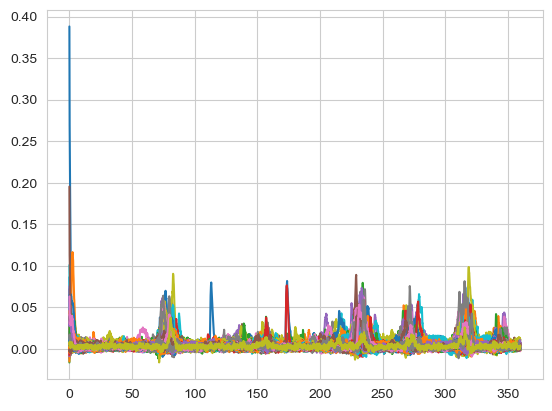

In [14]:
plt.plot(astro3.accepted_traces)

In [ ]:
# make sorted heatmaps for fc at time of shocks - average; z-scored; window=28
for annie in [astro_3R, astro_4R, astro_5R, astro_6R, astro_7R, astro_8R, astro_9R]:
    _, whole_eta, time = annie.eta_individual_cells([[120,180,240,300]], window=15)
    sequence_heat_plot(whole_eta, time)
    plt.savefig(f"/Users/suthardr/Desktop/{annie.animal}recall_sorted_heat_plot_avg_15sec.png")